In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.linalg as la

\begin{equation}
\dot{x} = Ax + Bu
\end{equation}

\begin{equation}
y = Cx
\end{equation}

\begin{equation}
\dot{w}_g = S_g w_g
\end{equation}

\begin{equation}
u = L_g w_g
\end{equation}

Consider a system where $A$ and $S_g$ are not Hurwitz. 



<bound method Axes.scatter of <Axes: >>

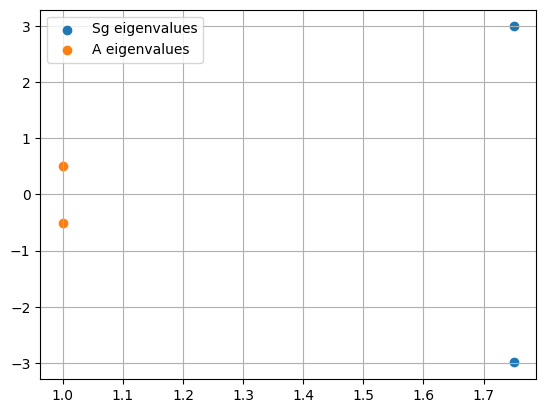

In [3]:
A = np.array([[1.0, -0.5],
              [0.5, 1.0]])

B = np.array([[0.],
              [1.]])

C = np.array([[1.0, 1.0]])

Sg = np.array([[2.0, -3.],
               [3., 1.5]])

Lg = np.array([[1.0, 1.0]])

def eigenvalue_list_creator(Sg):
    Re = []
    Im = []
    for z in np.linalg.eigvals(Sg):
        Re.append(np.real(z))
        Im.append(np.imag(z))
    return Re, Im

Re_Sg, Im_Sg = eigenvalue_list_creator(Sg)
Re_A, Im_A = eigenvalue_list_creator(A)


fig, ax = plt.subplots()
ax.scatter(Re_Sg, Im_Sg, label = 'Sg eigenvalues')
ax.scatter(Re_A, Im_A, label = 'A eigenvalues')

ax.legend()
ax.grid(True)
ax.scatter

Eigenvalues are not shared, and are both on the right handside. 
Now let's simulate the dynamics of the system, and look at the moment relationships. 

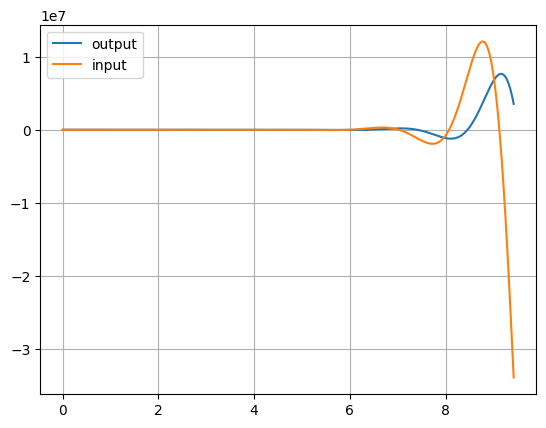

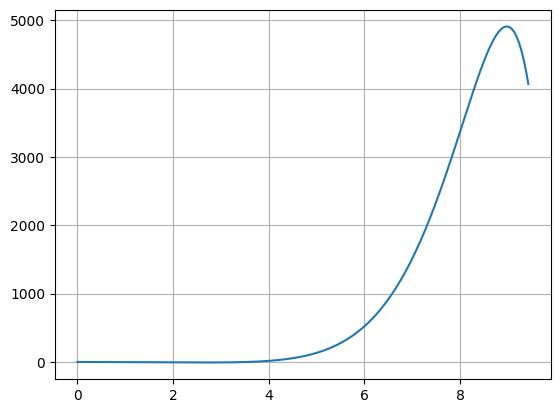

In [4]:
def system(t, state):
    x = state[:2]
    w = state[2:4]

    u = Lg @ w
    dx = A @ x + B.flatten() * u
    dw = Sg @ w
    return np.concatenate([dx, dw])

# Time conditions
t_span = (0., 3.0*np.pi)
t_eval = np.linspace(t_span[0], t_span[1], 10000)

# Initial conditions
x0 = [1.0, 0.2, 2.0, 0.5]
sol = solve_ivp(system, t_span, x0, t_eval=t_eval, method='Radau')

X = sol.y[:2, :]
Y = (C @ X).flatten()

W = sol.y[2:, :]
U = (Lg @ W).flatten()

# Moments
Pi_g = la.solve_sylvester(A, -Sg, -B @ Lg)
Mg = C @ Pi_g
moment_output = (Mg @ W).flatten()
diff = moment_output - Y


plt.figure(1)
plt.plot(sol.t, Y, label = 'output')
plt.plot(sol.t, U, label = 'input')
plt.grid(True)
plt.legend()

plt.figure(2)
plt.plot(sol.t, diff)
plt.grid(True)

plt.show()

For non-singularly-perturbed systems:
\begin{equation}
    \frac{d}{dt} \left( x - \Pi w_g \right) = A(x - \Pi w_g)
\end{equation}

For singularly perturbed systems: 


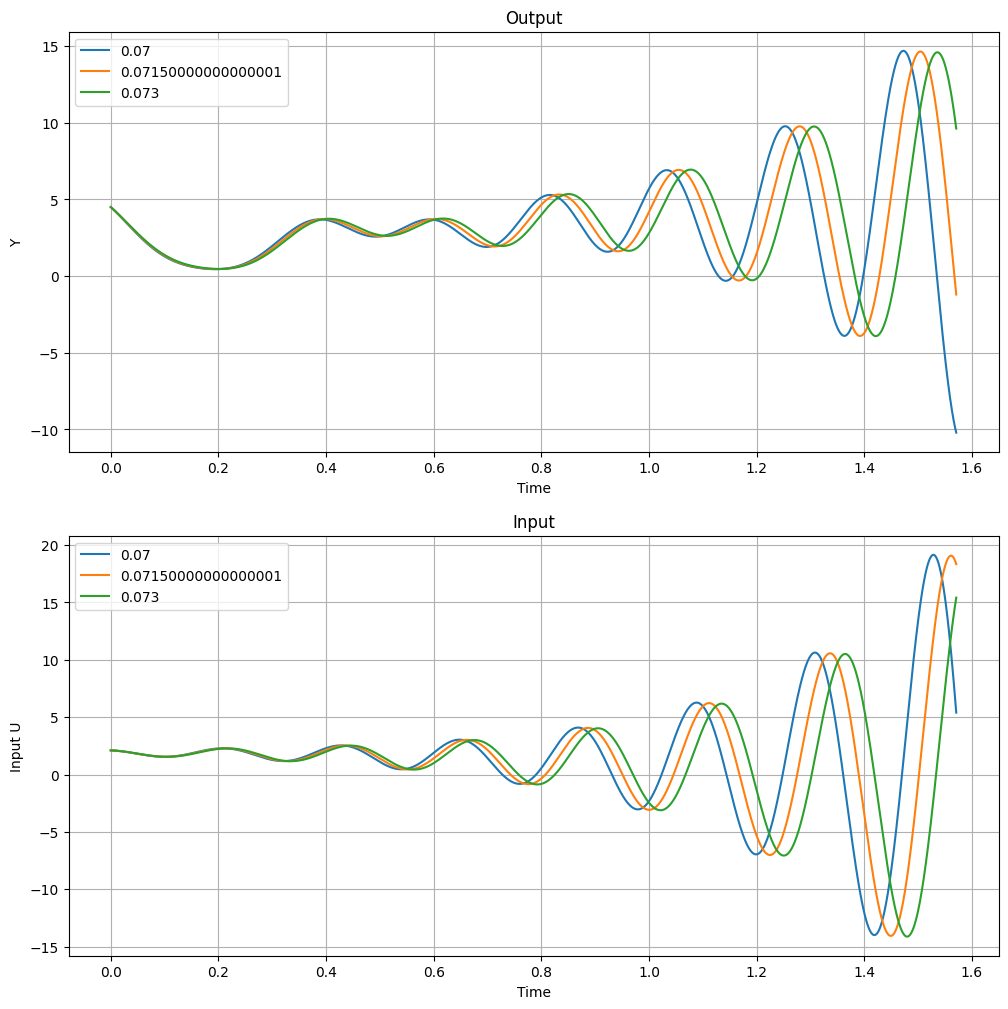

In [5]:
from dataclasses import dataclass

@dataclass
class SystemParams:
    n: int
    m: int
    Ng1: int
    Ng2: int
    A11: np.ndarray
    A12: np.ndarray
    A21: np.ndarray
    A22: np.ndarray
    S11: np.ndarray
    S12: np.ndarray
    S21: np.ndarray
    S22: np.ndarray
    Lg1: np.ndarray
    Lg2: np.ndarray
    B1: np.ndarray
    B2: np.ndarray
    epsilon: float

def combined_system(t, state, p: SystemParams):
    # Unpack states
    x = state[:p.n]
    z = state[p.n: p.n + p.m]
    w1 = state[p.n+p.m:p.n+p.m+p.Ng1]
    w2 = state[p.n+p.m+p.Ng1:p.n+p.m+p.Ng1+p.Ng2]

    # Input
    u = p.Lg1 @ w1 + p.Lg2 @ w2

    # Dynamics
    dx = p.A11 @ x + p.A12 @ z + p.B1.flatten() * u
    dz = (p.A21 @ x + p.A22 @ z + p.B2.flatten() * u) / p.epsilon
    dw1 = p.S11 @ w1 + p.S12 @ w2
    dw2 = (p.S21 @ w1 + p.S22 @ w2) / p.epsilon

    return np.concatenate([dx, dz, dw1, dw2])

# SETTING SYSTEM PARAMETERS

alpha = 1.0
beta = 0.5
A11 = np.array([[0., 1.],
                [-1., -beta]])
A12 = np.array([[0.,0.],
                [0.,beta]])
A21 = np.array([[0.,0.],
                [alpha, alpha * beta]])
A22 = np.array([[0., 1.0],
                [-1., -alpha * beta]])
B1 = np.array([[0.],
               [1.0]])
B2 = np.array([[0.],
               [-alpha]])

S11 = np.array([[0.1, -1.],
                [1. , 0.1]])
S12 = np.array([[0. , 0.1],
                [0.1 , 0.]])
S21 = np.array([[0., -0.1],
                [-0.1 , 0.]])
S22 = np.array([[0.2, -2.],
                [2. , 0.2]])

Sg = np.block([[S11,S12],
              [S21, S22]])

A_full0 = np.block([[A11, A12],
                    [A21, A22]])

# Time span
t_span = (0., 0.5*np.pi)
t_eval = np.linspace(t_span[0], t_span[1], 100000)

C1 = np.array([[1.0 , 1. ]])
C2 = np.array([[1. ,1. ]])

Y_all = []

# array of small values between 0 and 1 for epsilon
epsilon_list = np.linspace(0.07, 0.073, 3)

#initial conditions
state0 = [1., 1., 2.,0.5, 0.5, 0.5, 0.1, 0.1]

n = len(A11)
m = len(A22)
Ng1 = len(S11)
Ng2 = len(S22)

# same Lg as week 4
Lg = np.array([[(4.0-i)**0.5 for i in range(4)]])
Lg1 = Lg[0][:2]
Lg2 = Lg[0][2:]


plt.figure( figsize = (12,12))
for epsilon in epsilon_list:
    parameters = SystemParams(n, m, Ng1, Ng2, A11, A12, A21, A22,
                              S11, S12, S21, S22, Lg1, Lg2, B1, B2, epsilon)
    
    # solving the system for the given value in epsilon
    sol = solve_ivp(
        lambda t, state: combined_system(t, state, parameters),
        t_span, 
        state0, 
        t_eval = t_eval, 
        method = 'Radau'
    )
    
    X = sol.y[:n, :]
    Z = sol.y[n: n + m, :]
    W1 = sol.y[ n+m: n+m+Ng1, :]
    W2 = sol.y[ n+m+Ng1: n+m+Ng1+Ng2, :]
    U = Lg1 @ W1 + Lg2 @ W2

    Y = C1 @ X + C2 @ Z
    Y_all.append(Y.flatten())

    plt.subplot(2,1,1)
    plt.plot(sol.t, Y.flatten(), label = str(epsilon))
    plt.grid(True)
    plt.title("Output")
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Y")

    plt.subplot(2,1,2)
    plt.plot(sol.t, U.flatten(), label=str(epsilon))
    plt.grid(True)
    plt.title("Input")
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Input U")


Let's calculate the moments. 

In [6]:
epsilon_list2 = np.linspace(1e-5, 0.1, 1000)
Pi_x1_lst = []
Pi_x2_lst = []
Pi_z1_lst = []
Pi_z2_lst = []
for epsilon in epsilon_list2:
    parameters = SystemParams(n, m, Ng1, Ng2, A11, A12, A21, A22,
                              S11, S12, S21, S22, Lg1, Lg2, B1, B2, epsilon)
    
    k = 1/epsilon
    A_full = np.block([[A11, A12],
                       [k * A21, k * A22]])
    B_full = np.block([[B1],
                       [k * B2]])
    
    Sg = np.block([[S11, S12],
                   [k * S21, k * S22]])
    
    Pi_full = la.solve_sylvester( A_full, -Sg, -(B_full @ Lg))


    Pi_x1 = Pi_full[:2, :2]
    Pi_x2 = Pi_full[0:2, 2:4]
    Pi_z1 = Pi_full[2:4, 0:2]
    Pi_z2 = Pi_full[2: , 2:]

    Pi_x1_lst.append(la.norm(Pi_x1))
    Pi_x2_lst.append(la.norm(Pi_x2))
    Pi_z1_lst.append(la.norm(Pi_z1))
    Pi_z2_lst.append(la.norm(Pi_z2))

We define new variables $\theta$ and $\phi$: 
\begin{equation}
    \theta := x - \Pi_{x1} w_1 - \Pi_{x2} w_2
\end{equation}

\begin{equation}
    \phi := z - \Pi_{z1} w_1 - \Pi_{z2} w_2
\end{equation}

Then the system dynamics of $\theta$ and $\phi$ are also an autonomous LSP. 

In [7]:
def reduced_system(t, x):
    A22inv = la.inv(A22)
    dx = (A11 - A12 @ A22inv @ A21) @ x
    return dx

reduced_sol = solve_ivp(reduced_system, t_span, state0, method = 'Radau' )

X_red = reduced_sol.y[:n, :]

Y_red = C1 @ X_red

plt.plot(reduced_sol.t, Y_red.flatten())
plt.show()

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 8 is different from 2)